# Assignment 6

###### Piotr Stachowicz 337942

### Task 0 [3 points]

For all tasks in this assignment, use the RecBole package (https://recbole.io/) and the Amazon
Beauty datasets. Get familiar with the package. For using the package for the entire pipeline (loading
and splitting the data, training the model, evaluation), you can obtain 3 points. These points may
be added to any of the following tasks.

In [1]:
import pandas as pd
import numpy as np
from recbole.quick_start import run_recbole

run_recbole(
    model='Pop',
    dataset='beauty',
    config_dict={
        'data_path': './dataset',
        'epochs': 10,
        'train_batch_size': 2048,
        'show_progress': False,
        'eval_step': 1,
        # 'log_wandb': True,
        # 'wandb_project': 'ADM',
        # 'wandb_name': 'baseline_popular'
    }
)

01 May 16:44    INFO  ['/home/piotrs/masters/Advanced-Data-Mining/list6/.venv/lib/python3.12/site-packages/ipykernel_launcher.py', '-f', '/mnt/c/Users/pansm/AppData/Local/Temp/kernel-ed879fee-cef6-48cc-a49f-d9d7eb635a0914346011607651267596/connection.json', '--IPCompleter.use_jedi=False', '--IPKernelApp.log_level=INFO']
01 May 16:44    INFO  
General Hyper Parameters:
gpu_id = 0
use_gpu = True
seed = 2020
state = INFO
reproducibility = True
data_path = ./dataset/beauty
checkpoint_dir = saved
show_progress = False
save_dataset = False
dataset_save_path = None
save_dataloaders = False
dataloaders_save_path = None
log_wandb = False

Training Hyper Parameters:
epochs = 10
train_batch_size = 2048
learner = adam
learning_rate = 0.001
train_neg_sample_args = {'distribution': 'uniform', 'sample_num': 1, 'alpha': 1.0, 'dynamic': False, 'candidate_num': 0}
eval_step = 1
stopping_step = 10
clip_grad_norm = None
weight_decay = 0.0
loss_decimal_place = 4

Evaluation Hyper Parameters:
eval_args = {'

{'best_valid_score': 0.0071,
 'valid_score_bigger': True,
 'best_valid_result': OrderedDict([('recall@10', 0.0216),
              ('mrr@10', 0.0071),
              ('ndcg@10', 0.0103),
              ('hit@10', 0.0226),
              ('precision@10', 0.0023)]),
 'test_result': OrderedDict([('recall@10', 0.0196),
              ('mrr@10', 0.0067),
              ('ndcg@10', 0.0095),
              ('hit@10', 0.0204),
              ('precision@10', 0.002)])}

### Task 1 [2 points]
Train and evaluate the SASRec model.
Remember to split the data properly for the sequential recommendations (last user interaction for testing, second last user interaction for validation).
Calculate the metrics (at least recall and nDCG) for k = 5, 10, 20 (note that you don’t need to calculate the recommendations multiple times to do so).

In [2]:
run_recbole(
    model='SASRec',
    dataset='beauty',
    config_dict={
        'data_path': './dataset',
        'USER_ID_FIELD': 'user_id',
        'ITEM_ID_FIELD': 'item_id',
        'TIME_FIELD': 'timestamp',

        'epochs': 50,
        'train_batch_size': 256,
        'show_progress': False,
        'eval_step': 1,

        'train_neg_sample_args': None,

        'log_wandb': True,
        'wandb_project': 'ADM',
        'wandb_name': 'SASRec',

        'load_col': {
            'inter': ['user_id', 'item_id', 'rating', 'timestamp']
        },

        'eval_args': {
            'split': {'LS': 'valid_and_test'},
            'order': 'TO',
            'mode': 'full'
        },

        'metrics': ['Recall', 'NDCG'],
        'topk': [5, 10, 20],
        'valid_metric': 'NDCG@10'
    }
)

01 May 16:53    INFO  ['/home/piotrs/masters/Advanced-Data-Mining/list6/.venv/lib/python3.12/site-packages/ipykernel_launcher.py', '-f', '/mnt/c/Users/pansm/AppData/Local/Temp/kernel-ed879fee-cef6-48cc-a49f-d9d7eb635a0914346011607651267596/connection.json', '--IPCompleter.use_jedi=False', '--IPKernelApp.log_level=INFO']
01 May 16:53    INFO  
General Hyper Parameters:
gpu_id = 0
use_gpu = True
seed = 2020
state = INFO
reproducibility = True
data_path = ./dataset/beauty
checkpoint_dir = saved
show_progress = False
save_dataset = False
dataset_save_path = None
save_dataloaders = False
dataloaders_save_path = None
log_wandb = True

Training Hyper Parameters:
epochs = 50
train_batch_size = 256
learner = adam
learning_rate = 0.001
train_neg_sample_args = {'distribution': 'none', 'sample_num': 'none', 'alpha': 'none', 'dynamic': False, 'candidate_num': 0}
eval_step = 1
stopping_step = 10
clip_grad_norm = None
weight_decay = 0.0
loss_decimal_place = 4

Evaluation Hyper Parameters:
eval_args =

{'best_valid_score': 0.0522,
 'valid_score_bigger': True,
 'best_valid_result': OrderedDict([('recall@5', 0.0691),
              ('recall@10', 0.1041),
              ('recall@20', 0.1445),
              ('ndcg@5', 0.0408),
              ('ndcg@10', 0.0522),
              ('ndcg@20', 0.0624)]),
 'test_result': OrderedDict([('recall@5', 0.0559),
              ('recall@10', 0.0837),
              ('recall@20', 0.1186),
              ('ndcg@5', 0.0327),
              ('ndcg@10', 0.0417),
              ('ndcg@20', 0.0504)])}

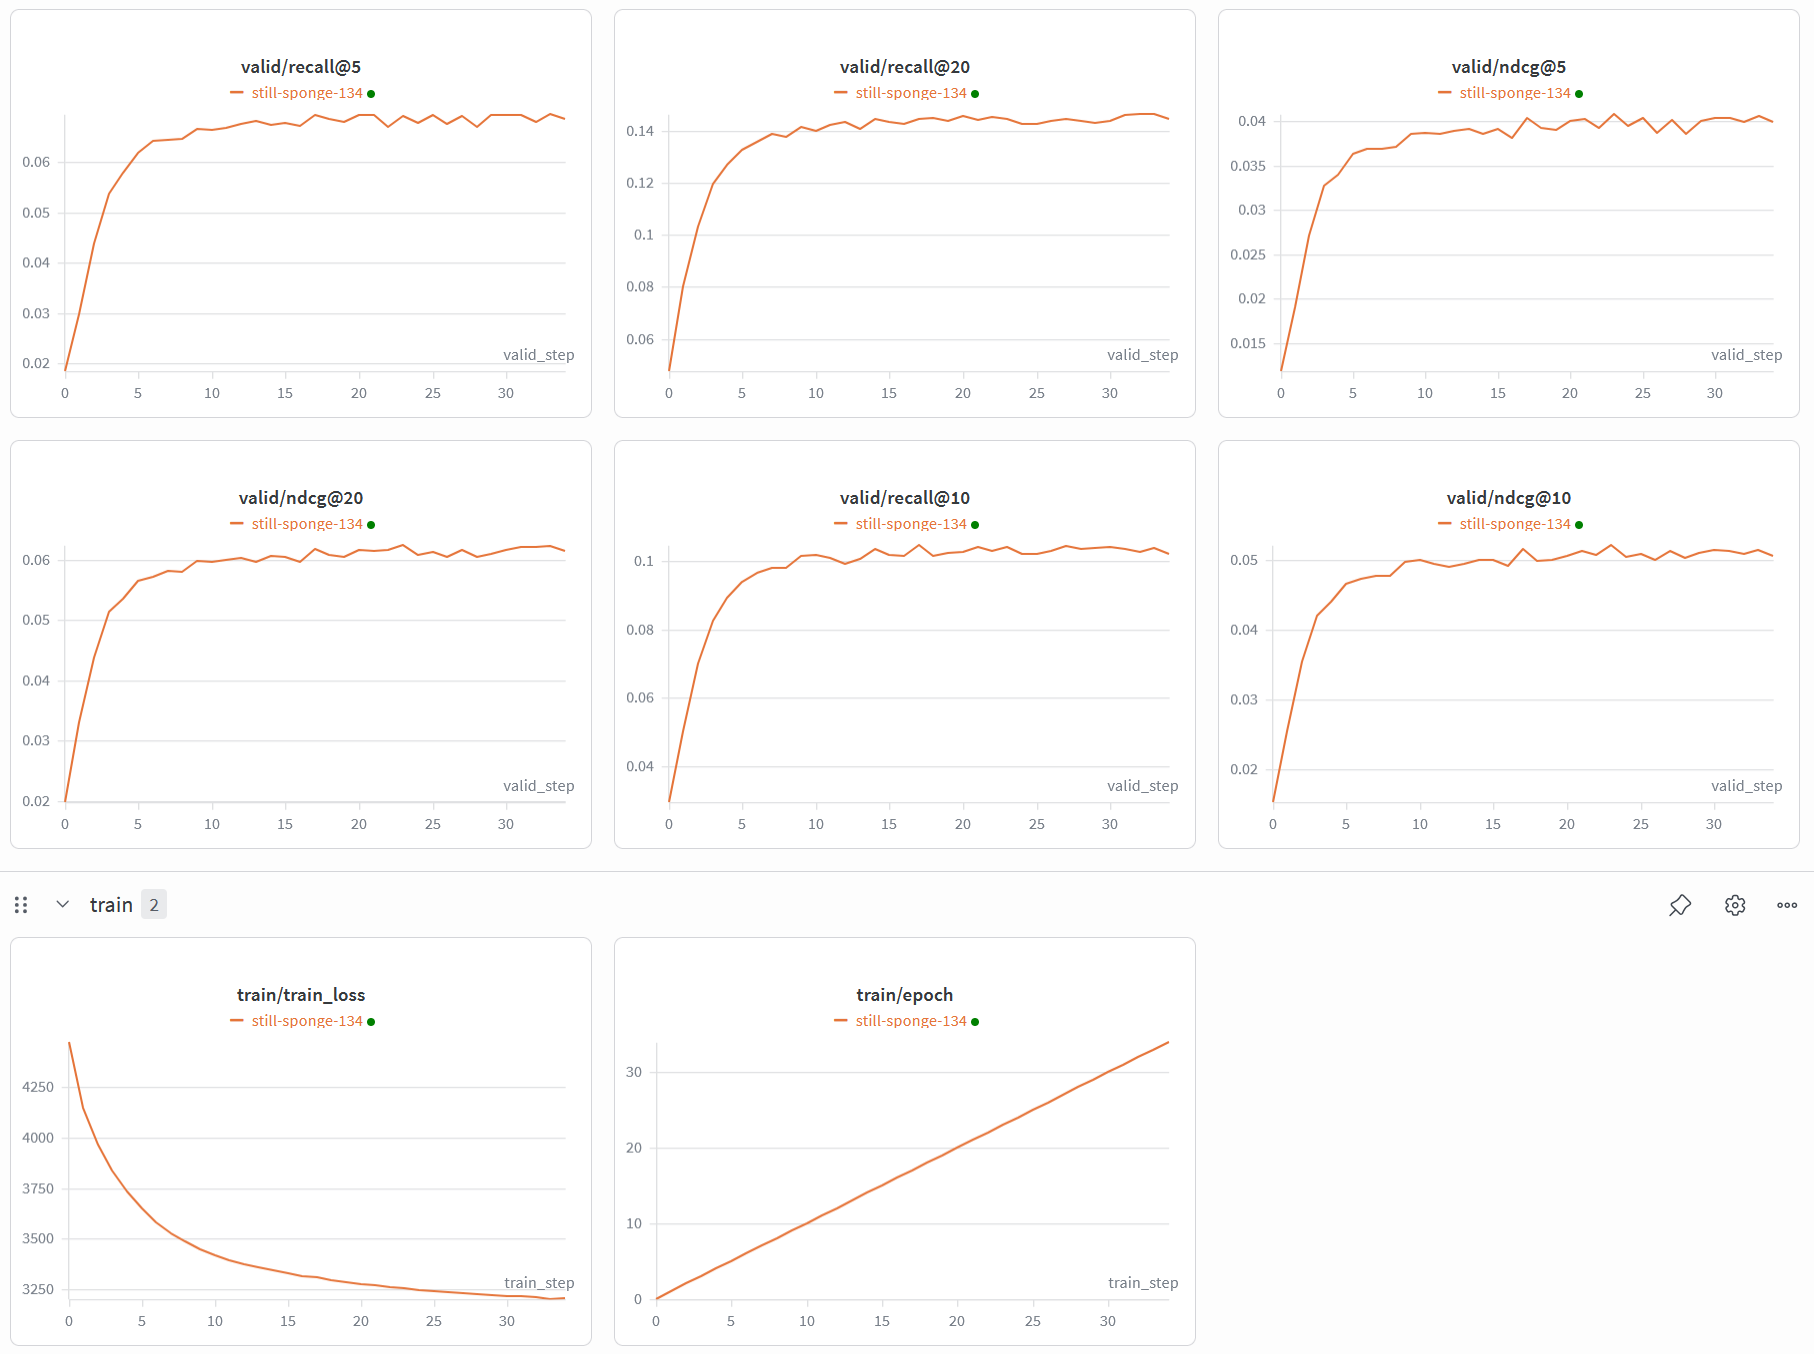

##### Load trained model

In [34]:
import matplotlib.pyplot as plt
from recbole.utils.case_study import full_sort_topk
from recbole.quick_start import load_data_and_model

checkpoint_path = 'saved/SASRec-beauty.pth'
config, model, dataset, train_data, valid_data, test_data = load_data_and_model(
    model_file=checkpoint_path,
)

test_df = test_data.dataset.inter_feat

01 May 17:53    INFO  
General Hyper Parameters:
gpu_id = 0
use_gpu = True
seed = 2020
state = INFO
reproducibility = True
data_path = ./dataset/beauty
checkpoint_dir = saved
show_progress = False
save_dataset = False
dataset_save_path = None
save_dataloaders = False
dataloaders_save_path = None
log_wandb = True

Training Hyper Parameters:
epochs = 50
train_batch_size = 256
learner = adam
learning_rate = 0.001
train_neg_sample_args = {'distribution': 'none', 'sample_num': 'none', 'alpha': 'none', 'dynamic': False, 'candidate_num': 0}
eval_step = 1
stopping_step = 10
clip_grad_norm = None
weight_decay = 0.0
loss_decimal_place = 4

Evaluation Hyper Parameters:
eval_args = {'split': {'LS': 'valid_and_test'}, 'order': 'TO', 'group_by': 'user', 'mode': {'valid': 'full', 'test': 'full'}}
repeatable = True
metrics = ['Recall', 'NDCG']
topk = [5, 10, 20]
valid_metric = NDCG@10
valid_metric_bigger = True
eval_batch_size = 4096
metric_decimal_place = 4

Dataset Hyper Parameters:
field_separator 

In [35]:
topk_scores, topk_index = full_sort_topk(
    test_df[config['USER_ID_FIELD']],
    model,
    test_data,
    20,
    config['device']
)

user_id = test_df[config['USER_ID_FIELD']].numpy()

/home/piotrs/masters/Advanced-Data-Mining/list6/.venv/lib/python3.12/site-packages/recbole/utils/case_study.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  uid_series = torch.tensor(uid_series)


##### Make predictions

...

Analyze the quality of recommendations for users with different sequence lengths:
- After performing the standard evaluation, divide the data based on the input sequence length (e.g. 0 − 5, 5 − 10, 15 − 20, 20 − 30, 30+).
- Calculate how many sequences fall into each group.
- Calculate the metrics for each group.
- Visualize the results in a clear form. Describe your observations.

In [36]:
unique_users, counts = np.unique(train_data.dataset.inter_feat[config['USER_ID_FIELD']].numpy(), return_counts=True)
hist_len = dict(zip(unique_users, counts))

In [39]:
results = []
for i, (user, pred) in enumerate(zip(user_id, rank_list)):
    ID = user.item()
    target = test_df[config['ITEM_ID_FIELD']][i].item()
    preds = pred.cpu()

    def get_recall(t, p, k):
        return 1 if t in p[:k] else 0

    def get_ndcg(t, p, k):
        if t in p[:k]:
            rank = np.where(p[:k] == t)[0][0]
            return 1 / np.log2(rank + 2)

        return 0

    r5 = get_recall(target, preds, 5)
    n5 = get_ndcg(target, preds, 5)

    r10 = get_recall(target, preds, 10)
    n10 = get_ndcg(target, preds, 10)

    r20 = get_recall(target, preds, 20)
    n20 = get_ndcg(target, preds, 20)

    length = hist_len[ID]

    results.append({
        'user_id': ID,

        'n@5': n5,
        'n@10': n10,
        'n@20': n20,

        'r@5': r5,
        'r@10': r10,
        'r@20': r20,

        'length': length
    })

In [40]:
result_df = pd.DataFrame(results)
result_df.head(5)

,user_id,n@5,n@10,n@20,r@5,r@10,r@20,length
0,225,0.0,0.0,0.0,0,0,0,116
1,269,0.0,0.0,0.0,0,0,0,7
2,1039,0.0,0.0,0.0,0,0,0,29
3,652,0.0,0.0,0.0,0,0,0,96
4,1296,0.0,0.0,0.0,0,0,0,2


In [41]:
bins = [0, 5, 10, 20, 50, result_df['length'].max()]
labels = ['1-5', '6-10', '11-20', '21-50', '50+']

result_df['bucket'] = pd.cut(result_df['length'], bins=bins, labels=labels)

In [44]:
# Group by bucket and calculate both mean and count
analysis = result_df.groupby('bucket', observed=False).agg({
    'r@5': 'mean',
    'r@10': 'mean',
    'n@5': 'mean',
    'n@10': 'mean',
    'user_id': 'count'
})

analysis.rename(columns={'user_id': 'group_size'}, inplace=True)
print(analysis)

             r@5      r@10       n@5      n@10  group_size
bucket                                                    
1-5     0.052035  0.076414  0.029643  0.037516       15874
6-10    0.054075  0.083524  0.032678  0.042103        3939
11-20   0.073171  0.110648  0.045240  0.057189        1681
21-50   0.099730  0.164420  0.064152  0.084665         742
50+     0.102362  0.165354  0.071132  0.090294         127


### Task 2 [2 points]
Train and evaluate the LightGCN model. Use a proper data split. Calculate the metrics (at least
recall and nDCG) for k = 5, 10, 20 (note that you don’t need to calculate the recommendations
multiple times to do so).

...

Analyze the popularity of items:
- Calculate the popularity of each item. Make a bar plot with ordered popularities (from largest to smallest).
- Analyze the popularity of the items you have recommended: how popular are the items you recommend, and how often items of different popularity are recommended.
- By doing this analysis, you can observe the Matthew effect for Recommender Systems.
Explain it.